# Generate source cataloges 

You can use this notebook as a starting point to generate your PlatoSim simulations needed for your GO proposal(s). This notebook build on the information from the `LightCurve.ipynb` tutorial.

Version: `PlatoSim 3.7.0-165-gae316c48`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
# Python standard
import os
import sys
import glob

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy import units as u

# PlatoSim functions
import platosim.plot      as pt
import platosim.utilities as ut 
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

### Load and plot PLATO-CS source catalogues

We assume that you have downloaded and placed the two catalogue files:
```
sources_PlatoCS_LOPS2_v1.ftr
sources_PlatoCS_LOPN1_v1.ftr
```
into your working directory called `plato-go/input` which is the folder of PlatoSim tutorials

In [27]:
# Change path to where you store your downloaded catalogues
pdir = Path(os.getenv('PLATO_WORKDIR')) / 'plato-go' / 'input'
path = Path(os.getenv('PLATO_WORKDIR')) / 'cs_stripped_stars'

In [28]:
ds = pd.read_feather(pdir / 'sources_PlatoCS_LOPS2_v1.ftr')
ds.gaiaDR3 = ds.gaiaDR3.astype('float64')
ds.head()

,gaiaDR3,ra,dec,l,b,Pmag,PBmag,PRmag,Gmag,BP_RP,...,R_upp,M,M_low,M_upp,L,L_low,L_upp,spec,evol,ncam
0,4.677206e+18,69.189319,-62.077491,272.671893,-39.342582,1.448518,3.785840,0.560105,1.958775,3.770394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
1,5.300300e+18,139.272369,-59.275176,278.459062,-7.011166,2.037026,2.179420,1.859075,2.213786,0.552959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
2,5.605797e+18,111.023738,-29.303083,242.616496,-6.485724,2.335989,2.418159,2.227041,2.450408,0.339532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
3,5.610442e+18,105.429755,-27.934809,239.168820,-10.273803,2.369039,3.053957,1.819715,2.760549,1.768627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K,<NA>,6
4,5.310394e+18,140.528323,-55.010611,275.882156,-3.537435,2.402990,2.461229,2.323981,2.487886,0.246693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6


In [39]:
dc = pd.read_csv(cdir / 'ConfirmedStrippedStars_GAIA_IDs.csv')
# Add Galactic coordinates
gal = SkyCoord(dc.ra, dc.dec, frame='icrs', unit=u.deg).galactic
dc['l'] = gal.l.deg
dc['b'] = gal.b.deg
dc.head()

,DR3Name,Source,ra,dec,U,e_U,B,e_B,V,e_V,I,e_I,galaxy,discovery_name,Class,RAdeg,DEdeg,l,b
0,Gaia DR3 4661246853006511616,4.660000e+18,76.194645,-69.04014,18.017064,0.065,18.299526,0.036,18.552299,0.055,19.341399,0.064,lmc,Star_6,1,76.194600,-69.040273,280.062671,-34.658439
1,Gaia DR3 4661234822846677120,4.660000e+18,77.167785,-69.18455,18.466064,0.320,18.736526,0.148,18.945299,0.103,19.813399,0.081,lmc,Star_10,2,77.167735,-69.184591,280.128099,-34.286521
2,Gaia DR3 4661236923031317888,4.660000e+18,77.205735,-69.09160,17.975064,0.057,18.024526,0.040,18.317299,0.049,19.074399,0.057,lmc,Star_5,1,77.205775,-69.091664,280.014951,-34.295666
3,Gaia DR3 4652191064838257280,4.650000e+18,77.846280,-69.89810,18.145064,0.052,18.109526,0.031,18.409299,0.086,19.172399,0.098,lmc,Star_11,2,77.846411,-69.898219,280.896426,-33.885927
4,Gaia DR3 4658215327673109888,4.660000e+18,78.345810,-69.37446,17.259064,0.049,17.130526,0.043,17.381299,0.137,17.662399,0.075,lmc,Star_19,3,78.345940,-69.374494,280.234604,-33.837087


In [40]:
dc.DR3Name

0     Gaia DR3 4661246853006511616
1     Gaia DR3 4661234822846677120
2     Gaia DR3 4661236923031317888
3     Gaia DR3 4652191064838257280
4     Gaia DR3 4658215327673109888
5     Gaia DR3 4658082321127720064
6     Gaia DR3 4658505804865450880
7     Gaia DR3 4658072008890332416
8     Gaia DR3 4658488143950771200
9     Gaia DR3 4658492198378960128
10    Gaia DR3 4657914336358688384
11    Gaia DR3 4657892238926979456
12    Gaia DR3 4657139416887392768
13    Gaia DR3 4657656462147291392
14    Gaia DR3 4657657737796215552
15    Gaia DR3 4657531049129312768
Name: DR3Name, dtype: object

In [41]:
# Query sources from Gaia DR3 database
df = pd.DataFrame()
for n in dc.DR3Name:
    try:
        dx = sq.simbadQuery(n, radius=15, maglim=21)
        dx['name'] = n
    except:
        print(n)
        pass
    else:
        df = pd.concat([df, dx.iloc[0].to_frame().T])

# Current data frame
cols = list(df)
cols.insert(0, cols.pop(cols.index('name')))
df = df.loc[:, cols]
df = df.drop(columns=['dis'])
df = df.reset_index(drop=True)

# Add galactic coordinates
gal = SkyCoord(df.ra, df.dec, frame='icrs', unit=u.deg).galactic
df['l'] = gal.l.deg
df['b'] = gal.b.deg
df

,name,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag,l,b
0,Gaia DR3 4661246853006511616,4661246853006511616,76.1946,-69.040273,18.600342,-0.368311,0.143664,0.19539,3.717236,1.57948,1.354259,10646.348633,4.4996,18.740179,280.062833,-34.658420
1,Gaia DR3 4661234822846677120,4661234822846677120,77.167735,-69.184591,18.888796,-0.429363,-0.015821,0.179898,2.126774,-0.207021,1.026322,9995.603516,4.6384,19.052616,280.128152,-34.286529
2,Gaia DR3 4661236923031317888,4661236923031317888,77.205775,-69.091664,18.399853,0.003941,0.294061,0.155373,2.070299,-1.431457,1.142893,15073.482422,4.6151,18.39843,280.015023,-34.295637
3,Gaia DR3 4652191064838257280,4652191064838257280,77.846411,-69.898219,18.540148,-0.23934,-0.005429,0.134401,1.481384,-0.863888,1.022438,11604.392578,4.4896,18.629784,280.896553,-33.885855
4,Gaia DR3 4658215327673109888,4658215327673109888,78.34594,-69.374494,17.34181,-0.205044,0.221349,0.069446,1.949824,0.19629,1.133288,15209.288086,4.6157,17.41827,280.234632,-33.837035
5,Gaia DR3 4658082321127720064,4658082321127720064,80.487185,-69.420924,15.982692,-0.339301,0.00942,0.038081,1.680646,0.270072,1.079211,19996.691406,4.3566,16.111168,280.103968,-33.090097
6,Gaia DR3 4658505804865450880,4658505804865450880,80.916027,-68.611394,18.02906,-0.385603,0.106165,0.091571,1.91344,0.133956,1.007293,15663.079102,4.6124,18.175682,279.120555,-33.084061
7,Gaia DR3 4658072008890332416,4658072008890332416,81.582347,-69.376181,18.846083,-0.353369,0.199621,0.155026,1.871999,0.401368,1.0309,NaN,NaN,18.980064,279.969922,-32.718847
8,Gaia DR3 4658488143950771200,4658488143950771200,81.697231,-68.823877,17.144089,-0.251326,-0.19544,0.076176,1.566136,0.368022,1.192389,16855.46875,4.5974,17.23835,279.314195,-32.769213
9,Gaia DR3 4658492198378960128,4658492198378960128,81.868035,-68.684404,18.989626,-0.201891,-0.451612,0.190295,0.916768,1.187752,1.076635,NaN,NaN,19.064878,279.138807,-32.730166


In [43]:
# Match to original catalogues to find targets within LOPs
df_match = df[df['gaiaDR3'].isin(ds['gaiaDR3'])] #.sort_values(by=['gaiaDR3'])
# df_match = df[df['gaiaDR3'].isin(dt['gaiaDR3'])].sort_values(by=['Gaia_ID'])
df_match

,name,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag,l,b
8,Gaia DR3 4658488143950771200,4658488143950771200,81.697231,-68.823877,17.144089,-0.251326,-0.19544,0.076176,1.566136,0.368022,1.192389,16855.46875,4.5974,17.23835,279.314195,-32.769213


<IPython.core.display.Javascript object>


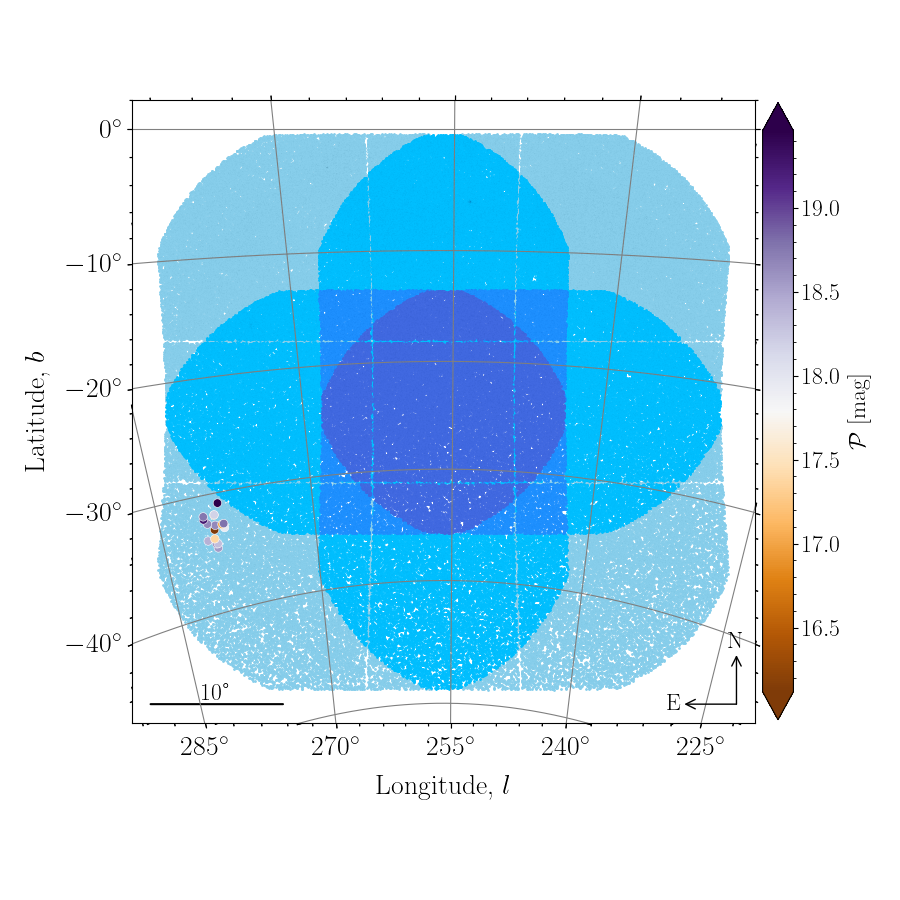

In [45]:
# dx = df.iloc[::100]
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=29, 
                          ncamStars=True, ncamMap='PIC210', showGalactic=True,
                          raStars=dc.ra, decStars=dc.dec, c=dc.V, s=150, lw=0.4, ec='w',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
# ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(path / 'stripped_stars_LOPS2.png', bbox_inches='tight', dpi=200)